In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy import signal

In [7]:
def salvartxt(nome, arrt, arry):
    with open(f'{nome}.txt', 'w') as f:
        for linha in range(len(arrt)):
            f.write(f'{arrt[linha]}\t{arry[linha]}\n')

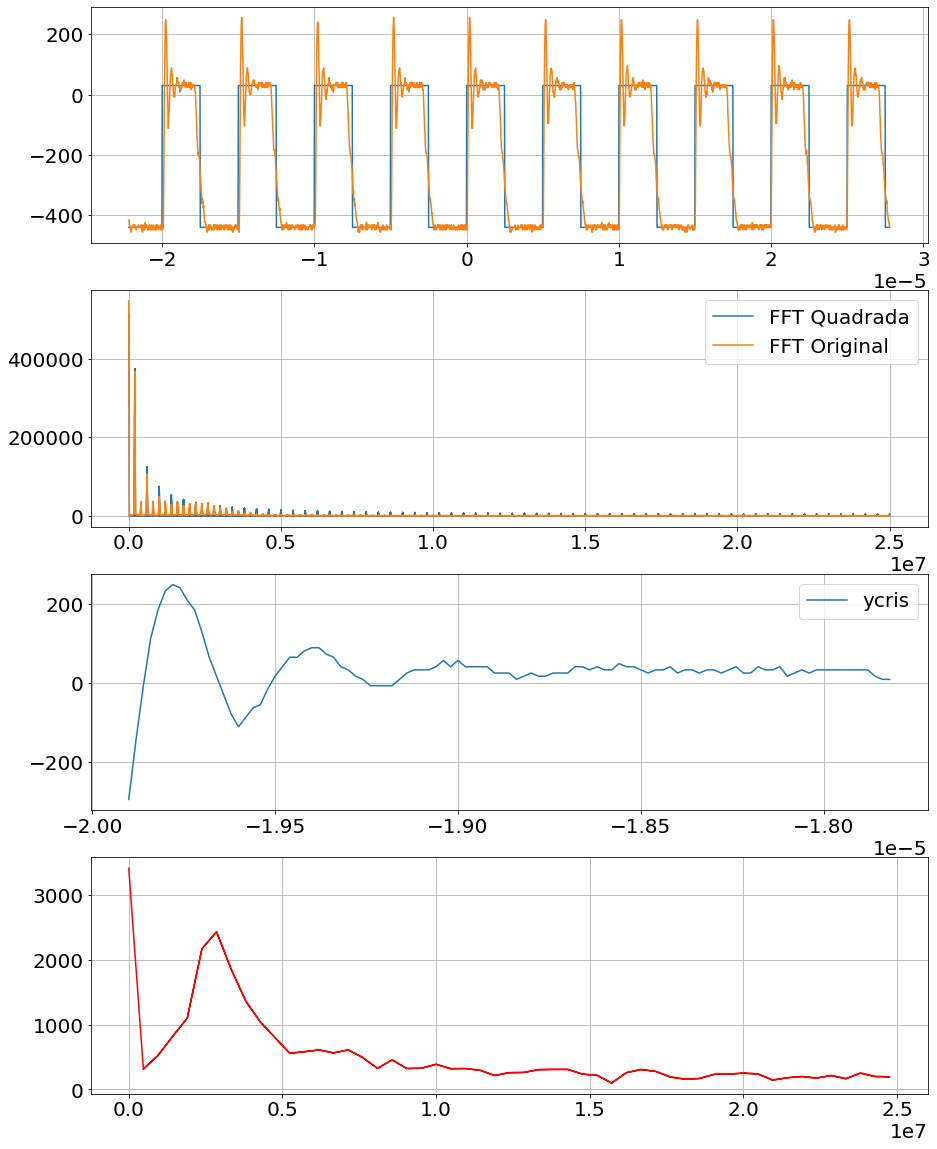

In [8]:
plt.rcParams['figure.figsize'] = [15,20]
plt.rcParams['font.size'] = 20

n = 2500
T = 200e3 * 2 * np.pi
x = np.array(np.linspace(-2.22e-5, 2.778e-5, n))
a = 235
y1 = a * signal.square(x*T) - 205

y_exp = np.loadtxt('curva_original.txt')
t = y_exp[:,0]
y2 = y_exp[:,1]

# Transformada quadrada
fft1 = np.fft.fft(y1)
freqs1 = np.fft.fftfreq(n, t[1] - t[0])

# Transformada original
fft2 = np.fft.fft(y2)
freqs2 = np.fft.fftfreq(n, t[1] - t[0])

plt.subplot(4,1,1)
plt.plot(x, y1)
plt.plot(t, y2)
plt.grid()

plt.subplot(4,1,2)
plt.plot(np.abs(freqs1), np.abs(fft1), np.abs(freqs2), np.abs(fft2))
plt.legend(('FFT Quadrada', 'FFT Original'))
plt.grid()

# Crista do sinal
d1 = 115 #ponto inicial (115)
d2 = 220 #ponto final (210)

tcris = y_exp[d1:d2,0]
ycris = y_exp[d1:d2,1]

fftCris = np.fft.fft(ycris)
freqsCris = np.fft.fftfreq(len(ycris), t[1] - t[0])

plt.subplot(4,1,3)
plt.plot(tcris, ycris, label='ycris')
plt.legend()
plt.grid()

plt.subplot(4,1,4)
plt.plot(np.abs(freqsCris), np.abs(fftCris), color='r')
plt.grid()

salvartxt('transformadas/FFTQuadrado', np.abs(freqs1), np.abs(fft1))
salvartxt('transformadas/FFTOriginal', freqs2, np.abs(fft2))
salvartxt('transformadas/FFTCrista', np.abs(freqsCris), np.abs(fftCris))
